In [1]:
using Pkg
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")
ENV["JULIA_REVISE_POLL"]="1";
using Revise

In [2]:
using PyPlot, PyCall, Peaks, Statistics, JJDFTX, DelimitedFiles;
using JJDFTX: kinetic_energy
interpolate = pyimport("scipy.interpolate").interp1d
lattice_vectors = loadlattice("wannier.out");
kpoints = bandstructkpoints2q(interpolate=5);

Your version of python is not linked to helper_scripts.py
Congratulations- Your version of python is linked to the Atomic Simulation Environment


In [3]:
HwannierUp, cell_mapUp = hwannier("wannierUp"), np.loadtxt("wannierUp.map.txt");
HwannierDn, cell_mapDn = hwannier("wannierDn"), np.loadtxt("wannierDn.map.txt");

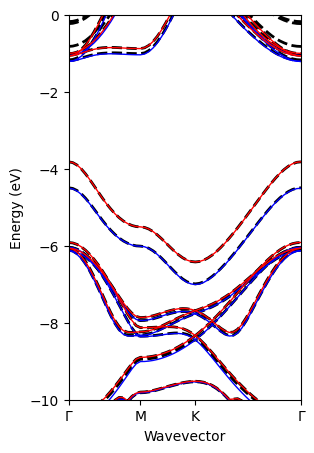

(-10.0, 0.0)

In [4]:
figure(figsize=(3, 5))
plot_bands(HwannierDn, cell_mapDn, color="black", linewidth=2, linestyle="dashed")
plot_bands(HwannierUp, cell_mapUp, color="black", linewidth=2, linestyle="dashed")

plot_bands("../BN3NC.bands.eigenvals", spin=2, whichbands=[4:15...], linewidth=1)
ylim(-10, 0)

In [7]:
Energies_Up, DOS_Up = density_of_states(HwannierUp, cell_mapUp, Val(2), histogram_width=100, mesh=20, monte_carlo=true, num_blocks=100)
Energies_Dn, DOS_Dn = density_of_states(HwannierDn, cell_mapDn, Val(2), histogram_width=100, mesh=20, monte_carlo=true, num_blocks=100)

([-23.71334017049532, -23.703339720904175, -23.69333927131303, -23.68333882172188, -23.673338372130733, -23.663337922539586, -23.65333747294844, -23.64333702335729, -23.633336573766144, -23.623336124174998  …  6.077999161531935, 6.087999611123081, 6.098000060714231, 6.108000510305377, 6.1180009598965235, 6.12800140948767, 6.13800185907882, 6.148002308669966, 6.158002758261112, 6.168003207852259], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

In [10]:
Es_up, Cs_up = find_chemical_potential(Energies_Up, DOS_Up)
Es_dn, Cs_dn = find_chemical_potential(Energies_Dn, DOS_Dn);

In [11]:
f_up =  interpolate(Es_up, Cs_up)
f_dn =  interpolate(Es_dn, Cs_dn)

PyObject <scipy.interpolate.interpolate.interp1d object at 0x7f17a4267540>

In [15]:
Energies = collect(range(-6.5, -3.6, length=10000))
Cs_tot = first.(f_up.(Energies)) + first.(f_dn.(Energies));
μ = Energies[argmin(abs.(Cs_tot .- 23))]
println("Chemical potential: $(μ)")
println("gμ: $(DOS_Up[argmin(abs.(Energies_Up .- μ))]+ DOS_Dn[argmin(abs.(Energies_Dn .- μ))])")

Chemical potential: -5.665586558655866
gμ: 0.9800000000000001


In [34]:
epsilons_default = zeros(50, 200);
energies = collect(range(0, 100, length=10000));
for (i, k) in enumerate(kpoints[1:50])
    i == 1 && continue
    polarizations = parse.(Float64, readlines("Plasmon.out-$i"))
    for (j, ω) in enumerate(range(0.05, 1.5, length=200))
        epsilons_default[i, j] = real(ϵ(k, lattice_vectors, ω, energies, smooth(polarizations, win_len=10), Val(2), 
                Val(:default), limit=20, δ=0.01, normalized=true))
        #ϵ(k, lattice_vectors, ω, energies, polarizations, δ=0.001, normalized=true)
    end
end

In [35]:
plasmon_default = [range(0.05, 1.5, length=200)[argmin(x)] for x in eachrow(log.(abs.(epsilons_default[2:15, :])))];
plasmon_default = [0, plasmon_default...]
qs_default, confinements = confinement(lattice_vectors, kpoints[1:15], plasmon_default)
confinements[1] = 0
plasmon_default = smooth(plasmon_default, win_len=1)
confinements = smooth(confinements, win_len=1);
plasmon_default[1] = 0
confinements[1] = 0;

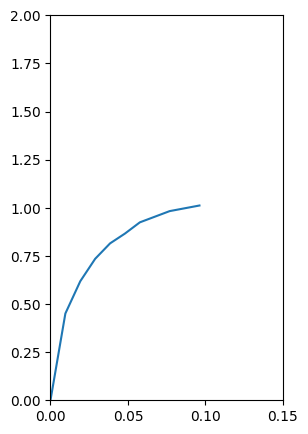

(0.0, 2.0)

In [36]:
figure(figsize=(3, 5))
plot(qs[1:11], plasmon_default[1:11])
xlim(0, 0.15)
ylim(0, 2)

In [37]:
epsilons_scipy = zeros(50, 200)
for i in 1:50
    epsilons_scipy[i, :] = np.loadtxt("Epsilon.out-$i")
end

In [38]:
plasmon_scipy = [range(0.05, 1.5, length=200)[argmin(x)] for x in eachrow(log.(abs.(smooth(epsilons_scipy[2:25, :], win_len=1))))];
plasmon_scipy = [0, plasmon_scipy...]
qs, confinements = confinement(lattice_vectors, kpoints[1:25], plasmon_scipy)
confinements[1] = 0
plasmon_scipy = smooth(plasmon_scipy, win_len=1)
confinements = smooth(confinements, win_len=1);
plasmon_scipy[1] = 0
confinements[1] = 0;

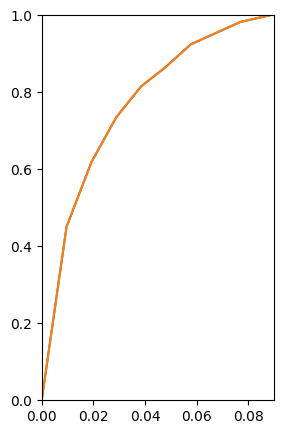

(0.0, 1.0)

In [46]:
figure(figsize=(3, 5))
plot(qs, plasmon_scipy)
plot(qs_default[1:11], plasmon_default[1:11])

xlim(0, 0.09)
ylim(0, 1)

In [71]:
np.savetxt("Plasmon.txt", hcat(qs, plasmon_scipy, confinements))

In [4]:
qs, plasmon_scipy, confinements = [collect(x) for x in eachcol(np.loadtxt("Plasmon.txt"))];

In [6]:
energies = collect(range(0, 100, length=10000));

landau_lower_alt = zeros(25);
landau_upper_alt = zeros(25);
for (i, k) in enumerate(kpoints[1:25])
    polarizations = parse.(Float64, readlines("Plasmon.out-$i"))
    non_zero_impols = energies[findall(.!iszero.(polarizations))]
    landau_lower_alt[i] = maximum([filter(x-> x < plasmon_scipy[i], non_zero_impols)..., 0])
    landau_upper_alt[i] = minimum(filter(x-> x > plasmon_scipy[i], non_zero_impols))
end

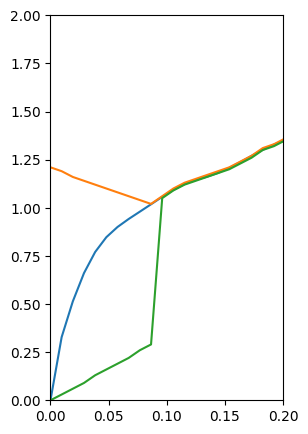

(0.0, 2.0)

In [20]:
figure(figsize=(3, 5))
plot(qs, plasmon_scipy)
plot(qs, landau_upper_alt)
plot(qs, landau_lower_alt)

xlim(0, 0.2)
ylim(0, 2)

In [21]:
np.savetxt("Landau.txt", hcat(qs, landau_lower_alt, landau_upper_alt))